In [1]:
import matplotlib.pyplot as plt
import torch

Available materials:
['Au', 'Ag', 'Cu', 'Al', 'SiO2', 'Si3N4', 'cSi', 'TiO2', 'aSi']


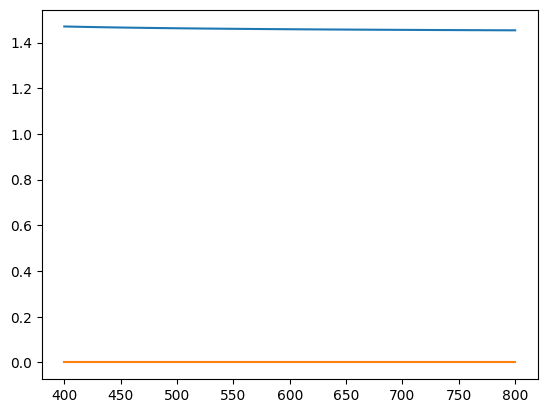

In [2]:
# Check dispersion
from dispertorch import material, list_materials
print(f"Available materials:")
print([mat for mat in list_materials().keys()])

au = material('SiO2')
wl = torch.linspace(400, 800, 41)

plt.plot(wl, au.n(wl))
plt.plot(wl, au.k(wl))


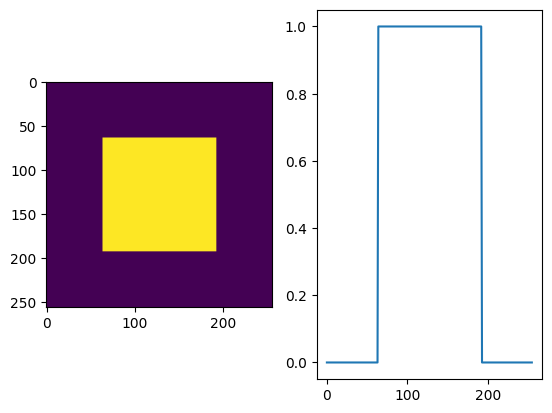

In [3]:
# chech shapes
from metashapes import Lattice, UnitCell
from metashapes.shape import Rectangle

Lx = 1.0
Ly = 1.0
lattice = Lattice.rectangular(Lx, Ly)

center = (0.5, 0.5)
size = (0.5, 0.5)
angle = 0
rect = Rectangle(center, size, angle=angle)

rect_cell = UnitCell(lattice, rect)
Nx = 256
Ny = 256

mask = rect_cell.mask(Nx, Ny, soft=False, softness=0.04)

plt.subplot(121)
plt.imshow(mask)

plt.subplot(122)
plt.plot(mask[128,:])

In [ ]:
# Test for shape_fn 

## Create a MetaShapes rectangle, lattice, call `shape_fn(lattice, nx, ny)` and check
## it returns a mask.

import matplotlib.pyplot as plt
from typing import Callable

import torch

from metashapes import UnitCell, Lattice
from metashapes.shape import Rectangle

# Lattice
Lx = 400
Ly = 400
lattice = Lattice.rectangular(Lx,Ly)

centre = (200,200)
size = (200,200)
angle = 0

rect = Rectangle(center=centre, size = size, angle=angle)

def from_metashapes(shape, soft, softness) -> Callable:
    """Convert a MetaShapes Shape object into a shape_fn(lattice, nx, ny):

    Parameters:
    ---------------
    shape:
        MetaShapes shape object

    soft: Boolean
        Inside our mask, every pixel will either be a 1 or 0 depending
        the material occupying that specific pixel. 

        0 to 1 gives a sudden jump at those boundaries.

        This gives discontinuity where the derivative is undefined at these
        jumps. PyTorch does a lot of gradient-based optimisations for which
        this wouldn't be ideal. 

    softness: Float
        The degree to which you smooth the boundary between the 0 and 1
        can be controlled using softness

    Returns
    -----------------
    Callable
        shape_fn(lattice, nx,ny)

        Arguments of shape:

            lattice:
                The shape input only gives the position, size and angle of the shape in the 
                unit cell. It doesn't give any information about the periodicity of this 
                unit cell. The lattice provides the lattice vectors, unit cell dimensions and the
                coordiante system (cartesian or fractional).
            grid resolution (nx,ny):
                This gives the number of pixels in the x and y direction of the unit cell. The higher
                the nx and ny, the higher the resolution.
    """

    try:
        from metashapes import UnitCell
    except:
        raise ImportError("You should have installed metashapes")
    
    def shape_fn(lattice, nx, ny):
        cell = UnitCell(lattice = lattice, scene=shape)
        return cell.mask(nx = nx, ny=ny, soft=soft, softness=softness)
    
    return shape_fn

shape_fn_0 = from_metashapes(rect, soft = True, softness = 0.01)

mask_0 = shape_fn_0(lattice, 256, 256)


In [ ]:
# Test for eps_fn

## Test epsilon with a material like gold:
## Create gold from DisperTorch, wrap it with `from_dispertorch`
## call `eps_fn(wl)` and inspect output


from dispertorch import material, list_materials

print(list_materials())

def from_dispertorch(dispersion) -> Callable:
    """ 
    Convers a DisperTorch dispersion model into eps_fn(wavelength).
    """
    def eps_fn(wl):
        return dispersion.permittivity(wl)

    return eps_fn

au = material("Au")
wl = torch.linspace(400,800,50)

eps_fn_0 = from_dispertorch(au)
eps_0 = eps_fn_0(wl)

print(eps_0.shape)
print(eps_0.dtype)

plt.plot(wl, eps_0.real, label = "Real component of permittivity")
plt.plot(wl, eps_0.imag, label = "Imaginary component of permittivity")
plt.legend()
plt.show()

In [ ]:
# Test layer
# Gold rectangle in Air with a thickness of 100

from src.metarcwa.model.layer import Layer
from src.metarcwa.model.stack import Stack

def air_fn(wl):
    return torch.ones_like(wl, dtype = torch.complex64)

layer_0 = Layer(
    eps_solid_fn = eps_fn_0,
    thickness = torch.tensor(100.0),
    eps_void_fn = air_fn,
    shape_fn = shape_fn_0
)

print(layer_0)
print(layer_0.thickness)


In [ ]:
# Create Stack
# Simple stack for testing where air in the incidence and transmission medium
# with layer_0 in between

stack = Stack(
    incidence = air_fn,
    layers = [layer_0],
    transmission = air_fn,
    lattice=lattice,
    grid_shape = (256,256)
)

print(stack)
print(stack.layers)

spec = stack.spec(wl)

print(spec.layer_eps.shape)
print(spec.layer_eps.dtype)
print(spec.layer_thickness)
print(spec.eps_incidence.shape)
print(spec.eps_transmission.shape)